# Density Matrices notes + demo (ePSproc + PEMtk dev.)
30/08/21, 24/07/24

In this notebook density matrices are considered & numerical routines demonstrated.

24/07/24: Updated notes and added density matrix from spherical tensor example.

## Density Matrices

The general density operator, for a mixture of indepent states $|\psi_{n} \rangle$, can be defined as (Eqn. 2.8, Blum [1]):

\begin{equation}
\hat{\rho}=\sum_{n}W_{n}|\psi_{n}\rangle\langle\psi_{n}|
\end{equation}

Where $W_{n}$ defines the (statistical) weighting of each state $\psi_{n}$ in the mixture.

For a given basis set, $|\phi_{m}\rangle$, the states can be expanded and the matrix elements of $\boldsymbol{\rho}$ defined (Eqns. 2.9 - 2.11, Blum [1]):
\begin{equation}
| \psi_{n} \rangle = \sum_{m'} a_{m'}^{(n)}| \phi_{m'}\rangle
\end{equation}

\begin{equation}
\hat{\rho}=\sum_{n}\sum_{mm'}W_{n}a_{m'}^{(n)}a_{m}^{(n)*}|\phi_{m'}\rangle\langle\phi_{m}|
\end{equation}

And the matrix elements - _the density matrix_ - given explicitly as:

\begin{equation}
\boldsymbol{\rho}_{i,j}=\langle\phi_{i}|\hat{\rho}|\phi_{j}\rangle=\sum_{n}W_{n}a_{i}^{(n)}a_{j}^{(n)*}
\end{equation}

For all pairs of basis states $(i,j)$. This defines the density matrix in the $\{|\phi_n\rangle\}$ _representation_ (basis space).

The expectation value of an operator $\hat{Q}$ can then be found as (Eqn. 2.18, Blum [1]):

\begin{eqnarray}
\langle \hat{Q}\rangle & = & \sum_{n}\sum_{mm'}W_{n}a_{m'}^{(n)}a_{m}^{(n)*}\langle\phi_{m}|\hat{Q}|\phi_{m'}\rangle\\
 & = & \sum_{mm'}\langle\phi_{m'}|\hat{\rho}|\phi_{m}\rangle\langle\phi_{m}|\hat{Q}|\phi_{m'}\rangle\\
 & = & \mathrm{tr}(\rho Q)
\end{eqnarray}


For basic examples, in terms of $|J,M\rangle$ states and alignment, see the [Quantum Metrology with Photoelectrons notes](https://github.com/phockett/Quantum-Metrology-with-Photoelectrons/blob/master/Alignment/Alignment-1.ipynb).

Here, we'll look at applying the formalism to photoionization, using `ePSproc` for the numerics...

[1] Blum, K. (2012). Density Matrix Theory and Applications (3rd Editio, Vol. 64). Berlin, Heidelberg: Springer Berlin Heidelberg. https://doi.org/10.1007/978-3-642-20561-3

## Setup

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
# import epsproc as ep
import xarray as xr

import matplotlib.pyplot as plt

from datetime import datetime as dt
timeString = dt.now()

import epsproc as ep

# Multijob class dev code
from epsproc.classes.multiJob import ePSmultiJob

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


* sparse not found, sparse matrix forms not available. 
* natsort not found, some sorting functions not available. 


* Setting plotter defaults with epsproc.basicPlotters.setPlotters(). Run directly to modify, or change options in local env.


* Set Holoviews with bokeh.
* pyevtk not found, VTK export not available. 


In [2]:
epDemoDataPath = Path(ep.__path__[0]).parent/'data'/'photoionization'/'n2_multiorb'

### Load test data

In [3]:
# Class dev code
from epsproc.classes.multiJob import ePSmultiJob
from epsproc.classes.base import ePSbase

# Instantiate class object.
# Minimally this needs just the dataPath, if verbose = 1 is set then some useful output will also be printed.
data = ePSbase(epDemoDataPath, verbose = 1)

# ScanFiles() - this will look for data files on the path provided, and read from them.
data.scanFiles()


*** Job orb6 details
Key: orb6
Dir /home/jovyan/code-share/github-share/ePSproc/data/photoionization/n2_multiorb, 1 file(s).
{   'batch': 'ePS n2, batch n2_1pu_0.1-50.1eV, orbital A2',
    'event': ' N2 A-state (1piu-1)',
    'orbE': -17.09691397835426,
    'orbLabel': '1piu-1'}

*** Job orb5 details
Key: orb5
Dir /home/jovyan/code-share/github-share/ePSproc/data/photoionization/n2_multiorb, 1 file(s).
{   'batch': 'ePS n2, batch n2_3sg_0.1-50.1eV, orbital A2',
    'event': ' N2 X-state (3sg-1)',
    'orbE': -17.34181645456815,
    'orbLabel': '3sg-1'}


## Density matrix functions - demo with photoionization matrix elements

As of ePSproc v1.3.1-dev [commit f5e4019](https://github.com/phockett/ePSproc/commit/f5e4019686aa3a24e9fff19b273b4b03372cfe19), density matrix routines are implemented in :py:func:`epsproc.calc.density` (functional forms only).

Note this currently requires [Holoviews](http://holoviews.org/) for plotting.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
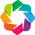

In [4]:
# Import routines
from epsproc.calc import density

### Set data

The routines are not currently wrapped by the main data class, so we'll just use a single sample dataset here.

In [5]:
# Set data from master class
k = 'orb5'  # N2 orb5 (SG) dataset
matE = data.data[k]['matE']
selDims = {'Type':'L'}
thres = 1e-2

Plotting data n2_3sg_0.1-50.1eV_A2.inp.out, pType=a, thres=0.01, with Seaborn


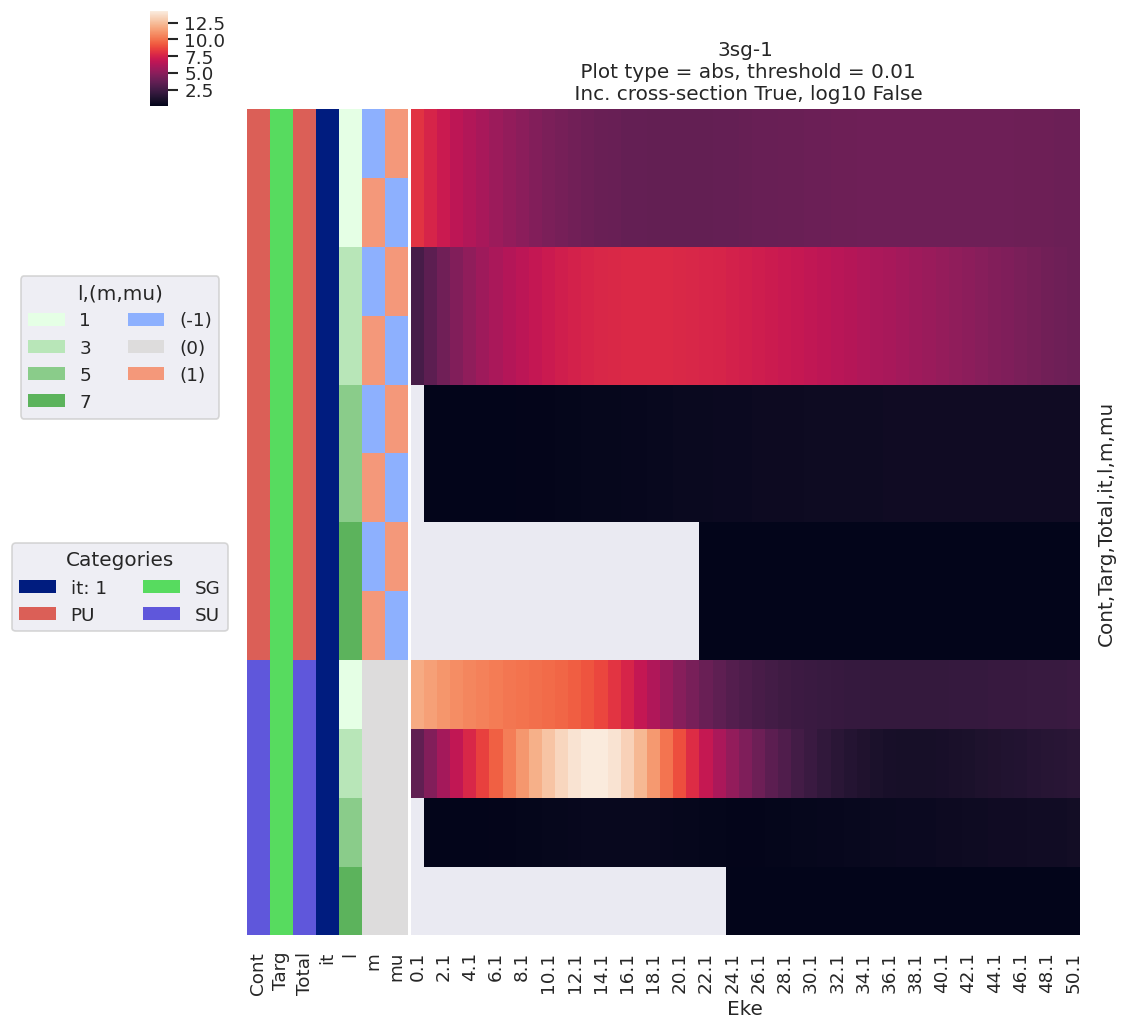

In [6]:
# Check data with lmPlot()
ep.lmPlot(matE, selDims = selDims, thres = thres);

### Calculate density matrix

The numerics essentially computer the outer product from the specified dimensions, as per the previous definition:

\begin{equation}
\boldsymbol{\rho}_{i,j}=\langle\phi_{i}|\hat{\rho}|\phi_{j}\rangle=\sum_{n}W_{n}a_{i}^{(n)}a_{j}^{(n)*}
\end{equation}

where $a_{i}^{(n)}a_{j}^{(n)*}$ are the values along the specified dimensions/state vector/representation. These dimensions must be in data, but will be restacked as necessary to define the effective basis space. For instance, from the ionization matrix element data shown above, setting `[l,m]` would select the $|\alpha\rangle = |l,m\rangle$ basis (equivalently `LM`, since the dimensions are already stacked in the ionization matrix elements). Setting `['LM','mu']` would set the $|\alpha\rangle = |l,m,\mu\rangle$ as the basis vector and so forth, where $|\alpha\rangle$ is used as a generic state vector denoting all required quantum numbers.

Note, however, that this selection is purely based on the numerics, which computes the outer product $|\alpha\rangle\langle\alpha'|$ to form the density matrix, hence does not guarantee a well-formed density matrix in the strictest sense (depending on the basis set), although will always present a basis state correlation matrix of sorts.

In [7]:
# Compose density matrix

# Set dimensions/state vector/representation
# These must be in original data, but will be restacked as necessary to define the effective basis space.
denDims = ['LM', 'mu']  

# Calculate
daOut, *_ = density.densityCalc(matE, denDims = denDims, selDims = selDims, thres = thres)  # OK

In [8]:
# The output is an Xarray, with a square density matrix in the specified dims (alpha, alpha'), where the latter is labelled '_p'.
# Other dims will be automatically stacked (unless otherwise specified).
daOut

<xarray.DataArray 'n2_3sg_0.1-50.1eV_A2.inp.out' (Eke: 51, Sym: 2, l,m,mu: 9,
                                                  l,m,mu_p: 9)>
array([[[[        nan       +nanj,         nan       +nanj,
                  nan       +nanj, ...,         nan       +nanj,
                  nan       +nanj,         nan       +nanj],
         [        nan       +nanj,  7.49604313+0.j        ,
                  nan       +nanj, ...,         nan       +nanj,
                  nan       +nanj,         nan       +nanj],
         [        nan       +nanj,         nan       +nanj,
                  nan       +nanj, ...,         nan       +nanj,
                  nan       +nanj,         nan       +nanj],
         ...,
         [        nan       +nanj,         nan       +nanj,
                  nan       +nanj, ...,         nan       +nanj,
                  nan       +nanj,         nan       +nanj],
         [        nan       +nanj,         nan       +nanj,
                  nan       +nanj, ...,         nan       +nanj,
                  nan       +nanj,         nan       +nanj],
         [        nan       +nanj,         nan       +nanj,
                  nan       +nanj, ...,         nan       +nanj,
                  nan       +nanj,         nan       +nanj]],

...

        [[ 0.66738586+0.j        ,         nan       +nanj,
           0.66738586+0.j        , ..., -0.08467309+0.06156213j,
                  nan       +nanj, -0.08467309+0.06156213j],
         [        nan       +nanj,         nan       +nanj,
                  nan       +nanj, ...,         nan       +nanj,
                  nan       +nanj,         nan       +nanj],
         [ 0.66738586+0.j        ,         nan       +nanj,
           0.66738586+0.j        , ..., -0.08467309+0.06156213j,
                  nan       +nanj, -0.08467309+0.06156213j],
         ...,
         [-0.08467309-0.06156213j,         nan       +nanj,
          -0.08467309-0.06156213j, ...,  0.01642143+0.j        ,
                  nan       +nanj,  0.01642143+0.j        ],
         [        nan       +nanj,         nan       +nanj,
                  nan       +nanj, ...,         nan       +nanj,
                  nan       +nanj,         nan       +nanj],
         [-0.08467309-0.06156213j,         nan       +nanj,
          -0.08467309-0.06156213j, ...,  0.01642143+0.j        ,
                  nan       +nanj,  0.01642143+0.j        ]]]])
Coordinates:
    Type      <U1 'L'
  * Sym       (Sym) MultiIndex
  - Cont      (Sym) object 'SU' 'PU'
  - Targ      (Sym) object 'SG' 'SG'
  - Total     (Sym) object 'SU' 'PU'
  * Eke       (Eke) float64 0.1 1.1 2.1 3.1 4.1 5.1 ... 46.1 47.1 48.1 49.1 50.1
    Ehv       (Eke) float64 17.4 18.4 19.4 20.4 21.4 ... 64.4 65.4 66.4 67.4
    SF        (Eke) complex128 (2.1560627+3.741674j) ... (4.4127053+1.8281945j)
  * l,m,mu    (l,m,mu) MultiIndex
  - l         (l,m,mu) int64 1 1 1 3 3 3 5 5 5
  - m         (l,m,mu) int64 -1 0 1 -1 0 1 -1 0 1
  - mu        (l,m,mu) int64 1 0 -1 1 0 -1 1 0 -1
  * l,m,mu_p  (l,m,mu_p) MultiIndex
  - l_p       (l,m,mu_p) int64 1 1 1 3 3 3 5 5 5
  - m_p       (l,m,mu_p) int64 -1 0 1 -1 0 1 -1 0 1
  - mu_p      (l,m,mu_p) int64 1 0 -1 1 0 -1 1 0 -1
Attributes:
    dataType:  Density Matrix
    file:      n2_3sg_0.1-50.1eV_A2.inp.out
    fileBase:  /home/jovyan/code-share/github-share/ePSproc/data/photoionizat...
    fileList:  n2_3sg_0.1-50.1eV_A2.inp.out
    jobLabel:  3sg-1
    density:   {'denSettings': {'da': <xarray.DataArray 'n2_3sg_0.1-50.1eV_A2...
    kdims:     ['l,m,mu', 'l,m,mu_p']

### Plotting density matrices

This is handled by the matPlot() routine. This uses [Holoviews](http://holoviews.org/) to compose a full-dimensional plot, as a set of matrices in the key dimensions $[\alpha,\alpha']$, and stacked in other dimensions. The plots are interactive + widgets for control, or can be pushed to a layout with Holoviews functionality.

In [9]:
# Plot full matrix
# This is interactive (with Holoviews), with the widgets allowing selection of other (stacked) dimensions.
# Plot types [real, imag, abs] are also set.
# Note this may take a while for data with a large number of dimensions.
density.matPlot(daOut)

Set plot kdims to ['l,m,mu', 'l,m,mu_p']; pass kdims = [dim1,dim2] for more control.


:HoloMap   [Sym,Eke,pType]
   :HeatMap   [l,m,mu,l,m,mu_p]   (n2_3sg_0.1-50.1eV_A2.inp.out)

In [10]:
# For more control, the Xarray and/or Holoviews object can be manipulated prior to plotting

hvmap = density.matPlot(daOut.sum('Sym').sel(Eke=slice(5,50,20)))  # Sum & slice data prior to plot
                                                                    # Note that summation may replace NaNs with zeros.
hvmap.layout('Eke').cols(1)  # Layout results by Eke, single column layout

Set plot kdims to ['l,m,mu', 'l,m,mu_p']; pass kdims = [dim1,dim2] for more control.


:NdLayout   [Eke]
   :HoloMap   [pType]
      :HeatMap   [l,m,mu,l,m,mu_p]   (n2_3sg_0.1-50.1eV_A2.inp.out)

TODO:

- Cmapping & dynamic map range control.
- NaN replacement issues?
- Normalisation.

## Density matrices from other data types

As defined above, an approximate density/correlation matrix can be composed from any Xarray. Strictly speaking, this may not always provide a well-formed density matrix, but will always provide a correlation matrix which may be interesting/informative for a given case.

Here we'll look at some other data-types, using the [AF-BLM routine](https://epsproc.readthedocs.io/en/dev/methods/ePSproc_geom_methods_summary_190821-v1-tidy.html) (strictly speaking, this defines a set of geometric tensors, which may have a direct relation with the corresponding density matrix - this [will be explored below](#Density-matrix-from-geometric-tensors), here we'll just do the numerics). For an more details of the AF-BLM routine see the [theory notes](https://epsproc.readthedocs.io/en/dev/methods/ePSproc_geom_methods_summary_190821-v1-tidy.html) and the [basis set exploration page](https://pemtk.readthedocs.io/en/latest/fitting/PEMtk_fitting_basis-set_demo_050621-full.html). (Note 24/07/24 update: results here are slightly different to previously, since AFBLM code now defaults to p=0/z-pol case, so R=0 terms only in default case.)

In [11]:
# Calculate AFPADs with full basis set return
# The default case will compute LF-BLM parameters
BetasNormX, basis = ep.afblmXprod(matE, selDims=selDims, basisReturn='Full', symSum=False)

In [12]:
# Basis set arrays
basis.keys()

dict_keys(['QNs', 'EPRX', 'lambdaTerm', 'BLMtable', 'BLMtableResort', 'AFterm', 'AKQS', 'polProd', 'phaseConvention', 'BLMRenorm', 'matEmult'])

In [13]:
# Compose density matrix

# Set dimensions/state vector/representation
# These must be in original data, but will be restacked as necessary to define the effective basis space.
denDims = 'BLM'

# Calculate
daOut, *_ = density.densityCalc(BetasNormX, denDims = denDims, selDims = selDims, thres = thres)  # OK

daOut.name = 'BLMplot' # Set name - note this can't be the same as a dimension!

# Plot
hvmap = density.matPlot(daOut.sel(Eke=slice(5,50,20)))  # Sum & slice data prior to plot
                                                                    # Note that summation may replace NaNs with zeros.
hvmap

Set plot kdims to ['BLM', 'BLM_p']; pass kdims = [dim1,dim2] for more control.


:HoloMap   [Sym,Eke,pType]
   :HeatMap   [BLM,BLM_p]   (BLMplot)

Not very interesting so far/in this case... but what about some of the basis tensors?

In [14]:
# Available basis arrays
basis.keys()

dict_keys(['QNs', 'EPRX', 'lambdaTerm', 'BLMtable', 'BLMtableResort', 'AFterm', 'AKQS', 'polProd', 'phaseConvention', 'BLMRenorm', 'matEmult'])

In [15]:
# Compose density matrix

termName = 'AFterm'
daIn = basis[termName]  # Set data

# Set dimensions/state vector/representation
# These must be in original data, but will be restacked as necessary to define the effective basis space.
denDims = ['P','Rp']

# Calculate + sum over other terms
daOut, *_ = density.densityCalc(daIn, denDims = denDims, selDims = selDims, thres = thres, sumDims=True, squeeze=False)  # Note may need squeeze=False for updated selectors if denDim maybe squeezed out!

daOut.name = termName # Set name - note this can't be the same as a dimension!

# Plot
hvmap = density.matPlot(daOut)  # Sum & slice data prior to plot
                                                                    # Note that summation may replace NaNs with zeros.
hvmap

{'L', 't', 'S-Rp', 'R', 'M'} set() {'L', 'R', 'M', 't', 'S-Rp'}
Set plot kdims to ['Rp,P', 'Rp,P_p']; pass kdims = [dim1,dim2] for more control.


:HoloMap   [pType]
   :HeatMap   [Rp,P,Rp,P_p]   (AFterm)

In this case, the Xarray already contains all the tensor components, so this calculation is somewhat redundant, as we can see from a closer inspection...

In [16]:
basis[termName]

<xarray.DataArray (P: 3, L: 3, R: 1, M: 1, Rp: 5, S-Rp: 5, t: 1)>
array([[[[[[[ 0.        ],
            [ 0.        ],
            [ 0.        ],
            [ 0.        ],
            [ 0.        ]],

           [[ 0.        ],
            [ 0.        ],
            [ 0.        ],
            [ 0.        ],
            [ 0.        ]],

           [[ 0.        ],
            [ 0.        ],
            [ 1.        ],
            [ 0.        ],
            [ 0.        ]],

           [[ 0.        ],
            [ 0.        ],
...
            [-0.2       ],
            [ 0.        ]],

           [[ 0.        ],
            [ 0.        ],
            [ 0.2       ],
            [ 0.        ],
            [ 0.        ]],

           [[ 0.        ],
            [-0.2       ],
            [ 0.        ],
            [ 0.        ],
            [ 0.        ]],

           [[ 0.2       ],
            [ 0.        ],
            [ 0.        ],
            [ 0.        ],
            [ 0.        ]]]]]]])
Coordinates:
  * P        (P) int64 0 1 2
  * L        (L) int64 0 1 2
  * R        (R) int64 0
  * M        (M) int64 0
  * Rp       (Rp) int64 -2 -1 0 1 2
  * S-Rp     (S-Rp) int64 -2 -1 0 1 2
  * t        (t) int64 0

Set dataType (No dataType)
Plotting data (No filename), pType=a, thres=0.01, with Seaborn


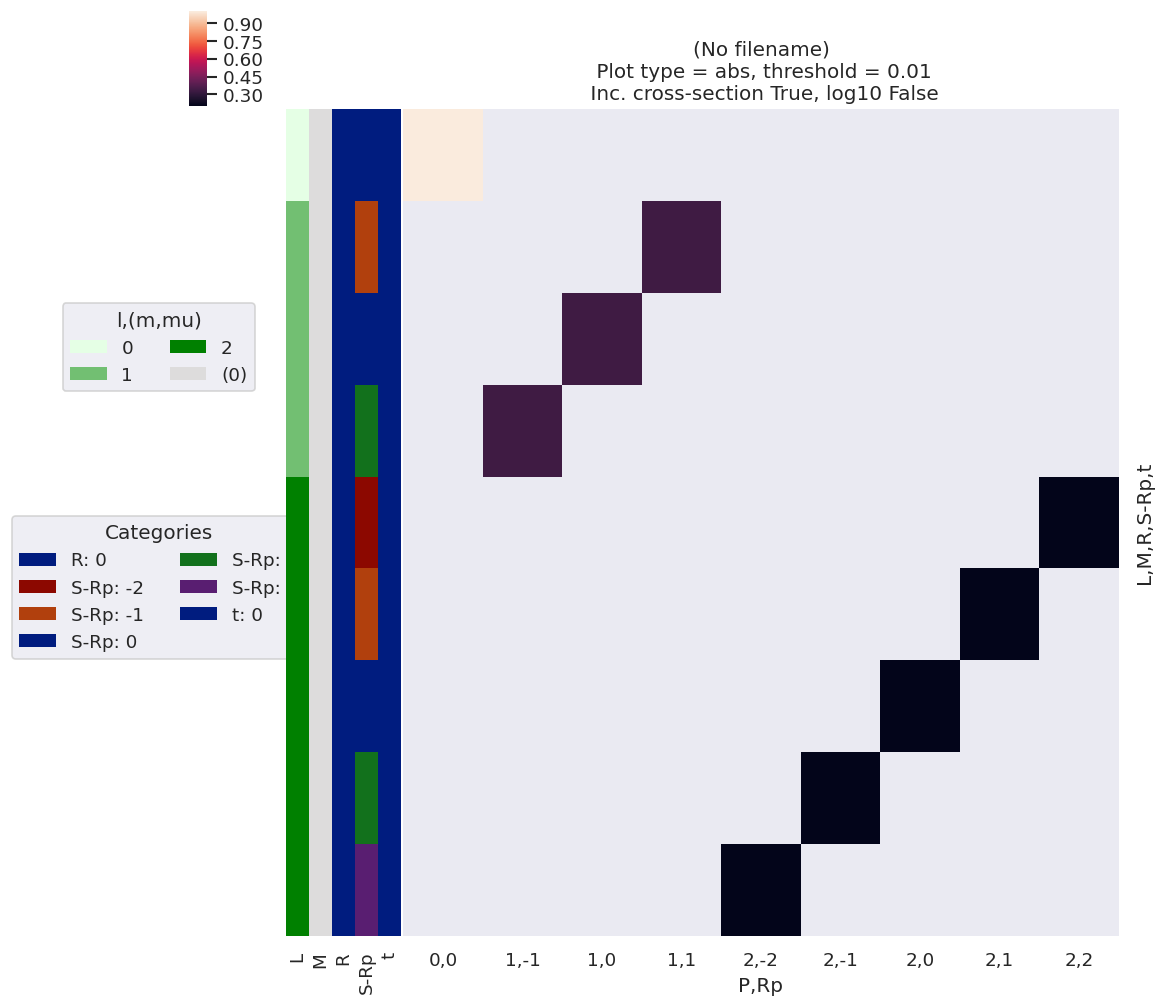

In [17]:
%matplotlib inline
# Use lmPlot to show the full dimensionality
ep.lmPlot(basis[termName], xDim={'PR':denDims});

In this case, we could also compose the density matrix directly by passing the relevant dims to the plotting function (all other dims will be stacked)...

(Two issues - plotting may be slow for multi-dim case, and many combinations may be zero/uninteresting.)

In [18]:
# Plot
daIn.name = termName # Set name - note this can't be the same as a dimension!
# hvmap = density.matPlot(daIn.squeeze(), kdims = ['P','Rp'])  # Sum & slice data prior to plot
                                                                    # Note that summation may replace NaNs with zeros.
hvmap = density.matPlot(daIn, kdims = ['R','Rp'])
hvmap

:HoloMap   [P,L,M,S-Rp,t,pType]
   :HeatMap   [R,Rp]   (AFterm)

In [19]:
# Compose density matrix

termName = 'lambdaTerm'  # 'AKQS' # Also needs fixing for single-value case?   # 'lambdaTerm'  # Needs fixing for singleton dim case!  # NOW OK if squeeze = False
daIn = basis[termName]  # Set data

# Set dimensions/state vector/representation
# These must be in original data, but will be restacked as necessary to define the effective basis space.
denDims = ['mu','mup']   # 'ADM'  #
daIn.name = termName

# Calculate + sum over other terms
daOut, *_ = density.densityCalc(daIn, denDims = denDims, selDims = selDims, thres = thres)  #, squeeze = False)  #, sumDims=True)  # OK

daOut.name = termName # Set name - note this can't be the same as a dimension!

# Plot
hvmap = density.matPlot(daOut)  # Sum & slice data prior to plot
                                                                    # Note that summation may replace NaNs with zeros.
hvmap

Set plot kdims to ['mu,mup', 'mu,mup_p']; pass kdims = [dim1,dim2] for more control.


:HoloMap   [Rp,P,pType]
   :HeatMap   [mu,mup,mu,mup_p]   (lambdaTerm)

In [20]:
ep.util.misc.checkDims(daIn, refDims = denDims)


{'dataDims': ('Rp', 'P', 'mu', 'mup', 'Labels'),
 'dataDimsUS': ('Rp', 'P', 'mu', 'mup', 'Labels'),
 'refDims': ['mu', 'mup'],
 'refDimsUS': ['mu', 'mup'],
 'shared': ['mu', 'mup'],
 'extra': ['Labels', 'Rp', 'P'],
 'extraUS': [],
 'invalid': [],
 'invalidUS': [],
 'stacked': [],
 'stackedMap': {},
 'stackedShared': [],
 'stackedExtra': [],
 'stackedComponents': [],
 'stackedInvalid': [],
 'missing': [],
 'safeStack': {},
 'stackedRef': False,
 'nonDimCoords': ['Euler'],
 'nonDimMap': {},
 'nonDimStacked': {},
 'nonDimDicts': {},
 'nonDimDims': {}}

## Density matrix from geometric tensors

As [discussed here](https://epsproc.readthedocs.io/en/dev/methods/ePSproc_geom_methods_summary_190821-v1-tidy.html), photoionization can be defined in terms of a set of geometric tensors (state multipoles). These are [intimately related to the density matrix](https://github.com/phockett/Quantum-Metrology-with-Photoelectrons/blob/master/Alignment/Alignment-1.ipynb#State-Multipoles), and can be thought of as a coupled basis equivalent. 

For example, in the $\{|JM\rangle\}$ representation (Eqn. 4.8 in Blum [1]):

\begin{equation}
\hat{T}(J',J)_{KQ}=\sum_{M'M}(-1)^{J'-M'}(2K+1)^{1/2}\left(\begin{array}{ccc}
J' & J & K\\
M' & -M & Q
\end{array}\right)|J'M'\rangle\langle JM|
\end{equation}

Where $\hat{T}(J',J)_{KQ}$ are tensor operators. The corresponding matrix elements are (Eqn. 4.9 in Blum [1]):

\begin{equation}
\langle J'M'|\hat{T}(J',J)_{KQ}|JM\rangle=(-1)^{J'-M'}(2K+1)^{1/2}\left(\begin{array}{ccc}
J' & J & K\\
M' & -M & Q
\end{array}\right)
\end{equation}

The density matrix can be written in terms of the tensor operators
(Eqn. 4.30 in Blum):

\begin{equation}
\boldsymbol{\rho}=\sum_{KQ}\sum_{J'J}\left[\sum_{M'M}\langle J'M'|\hat{\rho}|JM\rangle(-1)^{J'-M'}(2K+1)^{1/2}\left(\begin{array}{ccc}
J' & J & K\\
M' & -M & Q
\end{array}\right)\right]\hat{T}(J',J)_{KQ}
\end{equation}

And the state multipoles are defined as the term in square brackets
(Eqn. 4.31 in Blum):

\begin{equation}
\left\langle T(J',J)_{KQ}^{\dagger}\right\rangle =\sum_{M'M}\langle J'M'|\hat{\rho}|JM\rangle(-1)^{J'-M'}(2K+1)^{1/2}\left(\begin{array}{ccc}
J' & J & K\\
M' & -M & -Q
\end{array}\right)
\end{equation}

And the inverse (Eqn. 4.34 in Blum):

\begin{equation}
\langle J'M'|\hat{\rho}|JM\rangle=\sum_{KQ}(-1)^{J'-M'}(2K+1)^{1/2}\left(\begin{array}{ccc}
J' & J & K\\
M' & -M & -Q
\end{array}\right)\left\langle T(J',J)_{KQ}^{\dagger}\right\rangle 
\end{equation}

---

As [discussed above](#Density-matrices-from-other-data-types), the AF-$\beta_{LM}$ routines currently define a set of geometric tensors. These can be regarded & treated in general as state multipole type terms (although this is not strictly true in all cases) with appropriate summations. This means that the basis can be readily expressed in terms of mulitpoles or density matrices, and a few examples are given below.

(Note demos in previous section only plot existing tensors, but don't convert definitions.)

TODO: update matPlot & consolidate dim-handling routines from densityCalc to provide easier plotting routines here (without manual restack etc.).

### Density matrix from arb tensors

As of commit e2dcdd326e6e144fb4c442383ee096353314b17f, `densityFromSphTensor()` is available. This implements the final equation above (Eqn. 4.34 in Blum) to convert an input spherical tensor to density matrix form.

In [21]:
# Create arb time-dependent tensor using `setBLMs`
from epsproc.sphCalc import setBLMs
TKQ = setBLMs([[0,0,1,1,1,1,1,1],
               [1,0,0,0.5,0.8,1,0.5,0],[1,-1,0,0.5,0.8,1,0.5,0],[1,1,0,0.5,-0.5,1,0.5,0],
               [2,0,1,0.5,0,0,0.5,1],
               [4,2,0,0,0,0.5,0.8,1],[4,-2,0,0,0,0,-0.8,1]])
               # LMlabels = ['K','Q'], dimNames = ['KQ','t'])

# Rename dims to match arb case...
TKQ = TKQ.unstack('BLM').rename({'l':'K','m':'Q'}).stack({'KQ':['K','Q']})  #.fillna(0)  # Optional
TKQ.attrs['dataType']='TKQ'

# Compute density matrix
# Default case should work for preset datatypes, or pass dims for more control.
# Other dims should be handled/propagated transparently.
pmmFromTKQ = density.densityFromSphTensor(TKQ)

# Full results as Xarray, note default case may also keep input sph tensor dims, which should be summed over for the standard result.
pmmFromTKQ = pmmFromTKQ.sum(['K','Q'])
pmmFromTKQ

Set denDims={'JM': ['J', 'M'], 'JpMp': ['Jp', 'Mp']}. Pass directly for more control.
Set sphDims={'KQ': ['K', 'Q']}. Pass directly for more control.
['J', 'Jp']
['M', 'Mp']
['J', 'Jp', 'K', 'M', 'Mp', 'Q']


<xarray.DataArray 'BLM' (t: 6, JM: 45, JpMp: 45)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * t        (t) int64 0 1 2 3 4 5
  * JM       (JM) MultiIndex
  - J        (JM) int64 0 0 0 0 0 0 0 0 0 1 1 1 1 ... 3 3 3 3 4 4 4 4 4 4 4 4 4
  - M        (JM) int64 4 3 2 1 0 -1 -2 -3 -4 4 3 ... -4 4 3 2 1 0 -1 -2 -3 -4
  * JpMp     (JpMp) MultiIndex
  - Jp       (JpMp) int64 0 0 0 0 0 0 0 0 0 1 1 1 1 ... 3 3 3 4 4 4 4 4 4 4 4 4
  - Mp       (JpMp) int64 -4 -3 -2 -1 0 1 2 3 4 -4 ... 4 -4 -3 -2 -1 0 1 2 3 4

In [22]:
# from epsproc.sphFuncs.sphConv import cleanLMcoords
# # cleanLMcoords(pmmFromTKQ.sel(J=2,Jp=2).stack({'KQ': ['K', 'Q']}), refDims = ['K','Q'])
# pmmFromTKQ.sel(J=2,Jp=2)  #.stack({'KQ': ['K', 'Q']})

In [23]:
# Plot, optionally subselect and stack on dims (otherwise all dims will be available in widget)

# density.matPlot(pmmFromTKQ, kdims=['JM','JpMp'])   # All dims

density.matPlot(pmmFromTKQ.sel(J=2,Jp=2))  # With selected J,Jp

# density.matPlot(pmmFromTKQ.sel(J=2,Jp=2).stack({'KQ': ['K', 'Q']}), kdims=['M','Mp'])  # Select on J,Jp and restack sphDims for unsummed case

Set plot kdims to ['M', 'Mp']; pass kdims = [dim1,dim2] for more control.


:HoloMap   [t,pType]
   :HeatMap   [M,Mp]   (BLM)

### $B_{L,M}$ term

The coupling of the partial wave pairs, $|l,m\rangle$ and $|l',m'\rangle$, into the observable set of $\{L,M\}$ is [defined by a tensor contraction with two 3j terms](https://epsproc.readthedocs.io/en/latest/methods/geometric_method_dev_260220_090420_tidy.html#B_{L,M}-term).

\begin{equation}
B_{L,M}=(-1)^{m}\left(\frac{(2l+1)(2l'+1)(2L+1)}{4\pi}\right)^{1/2}\left(\begin{array}{ccc}
l & l' & L\\
0 & 0 & 0
\end{array}\right)\left(\begin{array}{ccc}
l & l' & L\\
-m & m' & M
\end{array}\right)
\end{equation}

Note for the AF case $B_{L,S-R'}(l,l',m,m')$ instead of $B_{L,-M}(l,l',m,m')$ for MF case. This allows for all MF projections to contribute (rather than a single specified polarization geometry).

This term, with a subset of elements defined for the photoionization matrix elements set previously, is (currently, v1.3.0) given by the 'BLMtableResort' basis array.

In [24]:
basis['BLMtableResort']

<xarray.DataArray 'w3jStacked' (m: 3, mp: 3, S-Rp: 5, l: 4, lp: 4, L: 8)>
array([[[[[[        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan]],

          [[        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan]],

          [[        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
...
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan]],

          [[        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan]],

          [[        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan],
           [        nan,         nan,         nan, ...,         nan,
                    nan,         nan]]]]]])
Coordinates:
  * L        (L) int64 0 2 4 6 8 10 12 14
  * m        (m) int64 -1 0 1
  * mp       (mp) int64 -1 0 1
  * S-Rp     (S-Rp) int64 -2 -1 0 1 2
  * l        (l) int64 1 3 5 7
  * lp       (lp) int64 1 3 5 7
Attributes:
    dataType:   betaTerm
    phaseCons:  {'phaseConvention': 'E', 'genMatEcons': {'negm': False}, 'EPR...

The lmPlot() routine can be used to show the full dimensionality...

In [25]:
# Plot BLM term with restack to standard LM terms
ep.lmPlot(basis['BLMtableResort'].rename({'S-Rp':'M'}).stack({'LM':['L','M']}), xDim={'LM':['L','M']});  

Plotting data (No filename), pType=a, thres=0.01, with Seaborn


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


The above shows, essentially, all the terms in the summation. By suitable summation we can look at the corresponding density matrix or state multipole.

In [26]:
# Compose density matrix

termName = 'BLMtableResort'  # 'AKQS' # Also needs fixing for single-value case?   # 'lambdaTerm'  # Needs fixing for singleton dim case!  # NOW OK if squeeze = False
daIn = basis[termName]  # Set data

# Reformat
daIn = daIn.rename({'S-Rp':'M'}).stack({'LM':['L','M'], 'lm':['l','m'], 'lmp':['lp','mp']})

# Set dimensions/state vector/representation
# These must be in original data, but will be restacked as necessary to define the effective basis space.
denDims = ['lm','lmp']   # 'ADM'  #
daIn.name = termName

hvmap = density.matPlot(daIn.sum('LM').squeeze(), kdims = denDims)

hvmap

:HoloMap   [pType]
   :HeatMap   [lm,lmp]   (BLMtableResort)

In [27]:
# Plot tensor BLM (state multipole) term with restack to standard LM terms
hvmap = density.matPlot(daIn.sum(['lm','lmp']).unstack(), kdims = ['L','M'])
hvmap

:HoloMap   [pType]
   :HeatMap   [L,M]   (BLMtableResort)

### Lambda terms

https://epsproc.readthedocs.io/en/dev/methods/ePSproc_geom_methods_summary_190821-v1-tidy.html#\Lambda-Term

In [28]:
# Compose density matrix

termName = 'lambdaTerm'  # 'AKQS' # Also needs fixing for single-value case?   # 'lambdaTerm'  # Needs fixing for singleton dim case!  # NOW OK if squeeze = False
daIn = basis[termName]  # Set data

# Set dimensions/state vector/representation
# These must be in original data, but will be restacked as necessary to define the effective basis space.
denDims = ['mu','mup']   # 'ADM'  #
daIn.name = termName

hvmap = density.matPlot(daIn.squeeze(), kdims = denDims)

In [29]:
hvmap

:HoloMap   [Rp,P,pType]
   :HeatMap   [mu,mup]   (lambdaTerm)

In [30]:
# Try with explicity summation over tensor (K,Q) dims...
# hvmap = density.matPlot(daIn.sum(['P','Rp']).squeeze(), kdims = denDims)  # Sum over P,Rp
hvmap = density.matPlot(daIn.sum('Rp').squeeze(), kdims = denDims)  # Sum over Rp only
hvmap.layout('P').cols(1)

:NdLayout   [P]
   :HoloMap   [pType]
      :HeatMap   [mu,mup]   (lambdaTerm)

In [31]:
# Full response function
# TODO: restacking + summation routine for general cases like this (with multiple existing dims).
basis['BLMtableResort'] * basis['polProd']

<xarray.DataArray (m: 3, mp: 3, S-Rp: 5, l: 4, lp: 4, L: 2, mu: 3, mup: 3,
                   Labels: 1, M: 1, t: 1)>
array([[[[[[[[[[[        nan+nanj]]],


              [[[        nan+nanj]]],


              [[[        nan+nanj]]]],



             [[[[        nan+nanj]]],


              [[[        nan+nanj]]],


              [[[        nan+nanj]]]],



...



             [[[[        nan+nanj]]],


              [[[        nan+nanj]]],


              [[[        nan+nanj]]]],



             [[[[        nan+nanj]]],


              [[[        nan+nanj]]],


              [[[        nan+nanj]]]]]]]]]]])
Coordinates:
  * L        (L) int64 0 2
  * m        (m) int64 -1 0 1
  * mp       (mp) int64 -1 0 1
  * S-Rp     (S-Rp) int64 -2 -1 0 1 2
  * l        (l) int64 1 3 5 7
  * lp       (lp) int64 1 3 5 7
  * mu       (mu) int64 -1 0 1
  * mup      (mup) int64 -1 0 1
    Euler    (Labels) object (0.0, 0.0, 0.0)
  * Labels   (Labels) <U1 'z'
  * M        (M) int64 0
  * t        (t) int64 0

## Versions

In [32]:
import scooby
scooby.Report(additional=['epsproc', 'holoviews', 'hvplot', 'xarray', 'matplotlib', 'bokeh'])

--------------------------------------------------------------------------------
  Date: Thu Jul 25 09:44:53 2024 EDT

                OS : Linux
            CPU(s) : 64
           Machine : x86_64
      Architecture : 64bit
               RAM : 62.8 GiB
       Environment : Jupyter
       File system : btrfs

  Python 3.10.11 | packaged by conda-forge | (main, May 10 2023, 18:58:44)
  [GCC 11.3.0]

           epsproc : 1.3.2-dev
         holoviews : 1.16.2
            hvplot : 0.8.4
            xarray : 2022.3.0
        matplotlib : 3.5.3
             bokeh : 3.1.1
             numpy : 1.23.5
             scipy : 1.10.1
           IPython : 8.13.2
            scooby : 0.7.2
--------------------------------------------------------------------------------

In [33]:
# Check current Git commit for local ePSproc version
from pathlib import Path
!git -C {Path(ep.__file__).parent} branch
!git -C {Path(ep.__file__).parent} log --format="%H" -n 1

* 3d-AFPAD-dev
  dev
  master
ba3d6780d95999e518caf85e08e80e7cbc68b6b2


In [34]:
# Check current remote commits
!git ls-remote --heads git://github.com/phockett/ePSproc

fatal: unable to connect to github.com:
github.com[0: 140.82.114.4]: errno=Connection timed out



In [35]:
!hostname

8fdb9101787f


In [36]:
!conda env list

# conda environments:
#
base                  *  /opt/conda

